In [1]:
# !pip install transformers

In [2]:
import os
import shutil
import sys
import json

import logging
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np


from transformers import pipeline
import torch

/Users/nadiaroschina/Library/Mobile Documents/com~apple~CloudDocs/masters_icloud/PROJECT/teeth_classes_classification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
logging.basicConfig(
    level=logging.WARNING,
    format="%(asctime)s [%(levelname)s] %(message)s"
)

In [4]:
# функция для преобразования сырого датасета в набор фотографий отдельного зуба

from utils_1_extract_teeth import extract_teeth

In [5]:
# простой CLIP-классификатор, нужен для работы extract_teeth

clip_classifier = pipeline(
    "zero-shot-image-classification",
    model="openai/clip-vit-base-patch32",
    device=0 if torch.cuda.is_available() else -1
)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 52312.15it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-20 02:00:21,313 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


In [12]:
# проверяем, что работает создание датасета
#   - в test/debug/grid сохраняется задетектированная решетка линий на картоне
#   - в test/debug/accepted и test/debug/rejected сохраняются фото зубов и пустые соответсвенно

extract_teeth(
    input_folder="dataset_raw/14/14",
    output_folder="test",
    clip_classifier=clip_classifier,
    debug=True
)

100%|██████████| 18/18 [00:35<00:00,  1.98s/it]


130

In [13]:
# создаем чистый датасет, используя как одиночные, так и групповые фотографии

RAW_DATASET_DIR = 'dataset_raw'
CLEAN_DATASET_DIR = 'dataset_clean'

os.makedirs(CLEAN_DATASET_DIR, exist_ok=False)

tooth_id = 0 
teeth_classes = [f'{x}{y}' for y in range(1, 9) for x in range(1, 5)]
tooth_id_to_class = {}

for cls in teeth_classes:

    # single photos
    img_files = [
        f for f in os.listdir(f"{RAW_DATASET_DIR}/{cls}")
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ]
    for file in img_files:
        shutil.copyfile(os.path.join(f"{RAW_DATASET_DIR}/{cls}", file), os.path.join(f"{CLEAN_DATASET_DIR}", f"{tooth_id:05d}.jpg"))
        tooth_id_to_class[tooth_id] = cls
        tooth_id += 1

    # group photos
    if os.path.exists(f"{RAW_DATASET_DIR}/{cls}/{cls}"):
        prev_tooth_id = tooth_id
        tooth_id = extract_teeth(
            input_folder=f"{RAW_DATASET_DIR}/{cls}/{cls}",
            output_folder=CLEAN_DATASET_DIR,
            clip_classifier=clip_classifier,
            debug=False,
            start_tooth_id=tooth_id,
        )
        for i in range(prev_tooth_id, tooth_id):
            tooth_id_to_class[i] = cls

with open(f"{CLEAN_DATASET_DIR}/tooth_id_to_class.json", "w") as f:
    json.dump(tooth_id_to_class, f)

print(f"total: {tooth_id} single tooth photos")

100%|██████████| 36/36 [00:51<00:00,  1.44s/it]

total: 3584 single tooth photos


In [14]:
from collections import Counter

Counter(tooth_id_to_class.values())

Counter({'36': 364,
         '47': 241,
         '46': 210,
         '48': 209,
         '15': 191,
         '25': 180,
         '24': 178,
         '37': 161,
         '27': 151,
         '14': 145,
         '38': 141,
         '35': 135,
         '44': 129,
         '41': 113,
         '34': 111,
         '42': 106,
         '23': 102,
         '33': 76,
         '31': 74,
         '45': 71,
         '43': 63,
         '17': 54,
         '11': 53,
         '32': 53,
         '21': 48,
         '22': 43,
         '28': 40,
         '26': 39,
         '18': 33,
         '12': 30,
         '16': 27,
         '13': 13})

<Axes: >

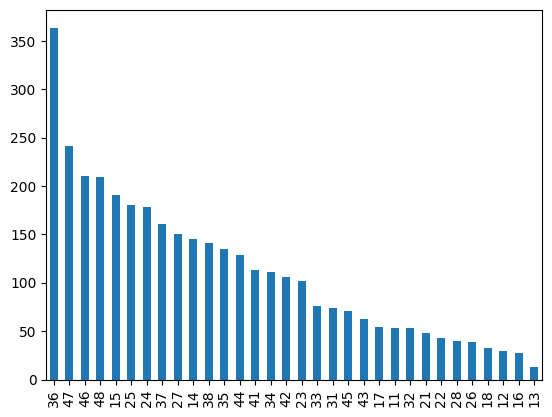

In [15]:
pd.Series(tooth_id_to_class.values()).value_counts().plot(kind='bar')